In [1]:
import sys, json, warnings
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.config import GROUNDTRUTH_DIR, PREDICTIONS_DIR, IMAGES_DIR
from src.evaluation.evaluate import load_prediction, get_available_models, estrai_basi

sns.set_style('ticks')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333333', 'axes.linewidth': 0.8,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.frameon': True,
    'legend.framealpha': 0.9, 'legend.edgecolor': '#cccccc',
    'font.size': 9,
})
print('Librerie caricate.')

Librerie caricate.


In [2]:
_DEPLOT_SUPPORTED = frozenset({'bar', 'line', 'pie'})
DATASETS = ['arXiv', 'PMCharts']

# Status categories:
#   ok            – file caricato con successo
#   unparseable   – file assente o non parseable
#   not_supported – DePlot su tipo non supportato


def _pred_file_exists(pred_dir, rel_path):
    p = pred_dir / rel_path
    return p.exists() or p.with_suffix('.txt').exists()


def collect_status(datasets=DATASETS, models=None):
    if models is None:
        models = get_available_models()

    records = []
    for dataset in datasets:
        img_base_dir = IMAGES_DIR / dataset
        if not img_base_dir.exists():
            continue
        chart_classes = sorted([d.name for d in img_base_dir.iterdir() if d.is_dir()])
        print(f'{dataset}: {chart_classes}')

        for chart_class in chart_classes:
            gt_dir = GROUNDTRUTH_DIR / dataset / chart_class
            if not gt_dir.exists():
                continue
            gt_files = sorted(gt_dir.rglob('*.json'))

            for gt_file in gt_files:
                try:
                    with open(gt_file, encoding='utf-8') as f:
                        gt_data = json.load(f)
                except Exception:
                    continue

                basi_gt = estrai_basi(gt_data)
                rel_path = gt_file.relative_to(gt_dir)

                for model in models:
                    is_deplot = model.lower() == 'deplot'

                    if is_deplot and chart_class not in _DEPLOT_SUPPORTED:
                        status = 'not_supported'
                    else:
                        pred_dir = PREDICTIONS_DIR / model / dataset / chart_class
                        pred_file = pred_dir / rel_path
                        if not pred_dir.exists() or not _pred_file_exists(pred_dir, rel_path):
                            status = 'unparseable'
                        else:
                            pred_data = load_prediction(pred_file, basi_gt)
                            status = 'ok' if pred_data is not None else 'unparseable'

                    records.append({
                        'model': model,
                        'dataset': dataset,
                        'chart_class': chart_class,
                        'filename': gt_file.name,
                        'status': status,
                        'n_datapoints': len(gt_data.get('data_points', [])),
                    })
    return pd.DataFrame(records)

In [3]:
warnings.filterwarnings('ignore')
df = collect_status()
warnings.filterwarnings('default')

print(f'Record totali : {len(df)}')
print(f'Modelli       : {sorted(df["model"].unique())}')
print()
print(df['status'].value_counts())

arXiv: ['bar', 'box', 'errorpoint', 'heatmap', 'histogram', 'line', 'pie', 'radar', 'scatter']
PMCharts: ['bar', 'box', 'bubble', 'errorpoint', 'heatmap', 'histogram', 'line', 'pie', 'radar', 'scatter']


Record totali : 7600
Modelli       : ['DePlot', 'InternVL2.5-2B', 'Phi3.5-Vision', 'Qwen2B', 'claude-sonnet-4-5', 'gemini-2.5-flash', 'gpt-4o', 'gpt-4o-mini']

status
ok               6777
not_supported     650
unparseable       173
Name: count, dtype: int64


## Conteggio e percentuale per modello × chart class

In [4]:
df['failed'] = df['status'] == 'unparseable'

totals = (
    df[df['status'] != 'not_supported']
    .groupby(['model', 'chart_class'])['filename']
    .count()
    .rename('total')
)
failed_count = (
    df[df['status'] != 'not_supported']
    .groupby(['model', 'chart_class'])['failed']
    .sum()
    .rename('failed')
)
summary = pd.concat([totals, failed_count], axis=1)
summary['pct'] = (summary['failed'] / summary['total'] * 100).round(1)

pivot_count = summary['failed'].unstack('chart_class').fillna(0).astype(int)
pivot_pct   = summary['pct'].unstack('chart_class').fillna(0)

print('--- Conteggio predizioni non parseable ---')
display(pivot_count)
print()
print('--- Percentuale (%) ---')
display(pivot_pct.round(1))

--- Conteggio predizioni non parseable ---


chart_class,bar,box,bubble,errorpoint,heatmap,histogram,line,pie,radar,scatter
model,,,,,,,,,,
DePlot,0,0,0,0,0,0,0,0,0,0
InternVL2.5-2B,1,0,0,1,58,4,6,2,9,6
Phi3.5-Vision,1,3,2,2,6,6,3,4,10,6
Qwen2B,0,1,2,0,11,0,2,10,6,1
claude-sonnet-4-5,1,0,9,0,0,0,0,0,0,0
gemini-2.5-flash,0,0,0,0,0,0,0,0,0,0
gpt-4o,0,0,0,0,0,0,0,0,0,0
gpt-4o-mini,0,0,0,0,0,0,0,0,0,0



--- Percentuale (%) ---


chart_class,bar,box,bubble,errorpoint,heatmap,histogram,line,pie,radar,scatter
model,,,,,,,,,,
DePlot,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
InternVL2.5-2B,1.0,0.0,0.0,1.0,58.0,4.0,6.0,2.0,9.0,6.0
Phi3.5-Vision,1.0,3.0,4.0,2.0,6.0,6.0,3.0,4.0,10.0,6.0
Qwen2B,0.0,1.0,4.0,0.0,11.0,0.0,2.0,10.0,6.0,1.0
claude-sonnet-4-5,1.0,0.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gemini-2.5-flash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gpt-4o,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gpt-4o-mini,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Heatmap percentuale predizioni mancanti/non valide

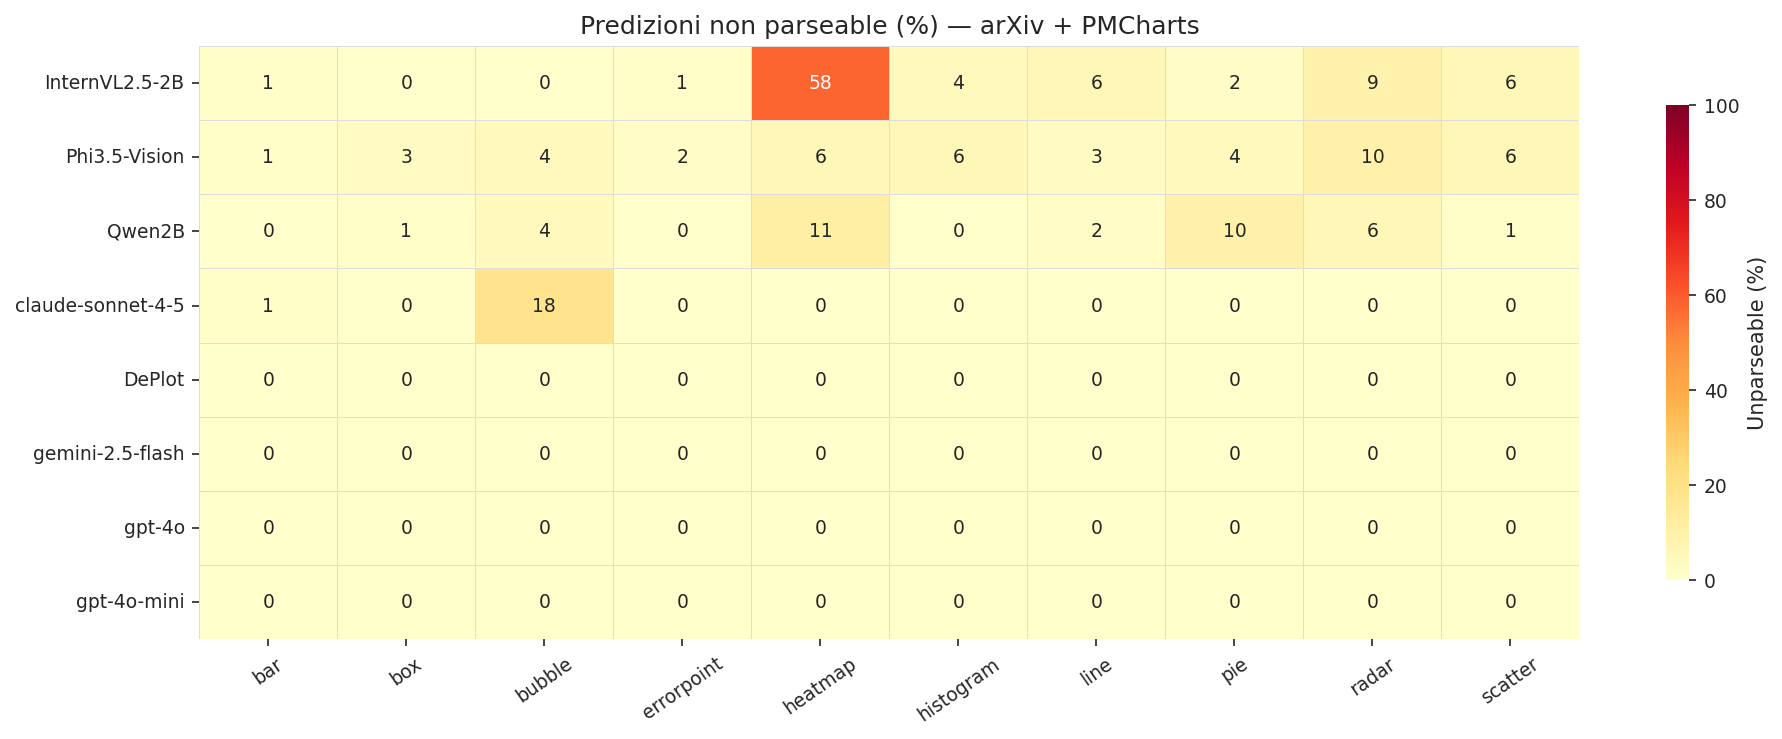

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

model_order = pivot_pct.mean(axis=1).sort_values(ascending=False).index.tolist()
cc_order = sorted(pivot_pct.columns)
data_plot = pivot_pct.loc[model_order, cc_order]

sns.heatmap(
    data_plot,
    annot=True, fmt='.0f', cmap='YlOrRd',
    vmin=0, vmax=100,
    linewidths=0.4, linecolor='#dddddd',
    cbar_kws={'label': 'Unparseable (%)', 'shrink': 0.8},
    ax=ax,
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Predizioni non parseable (%) — arXiv + PMCharts', fontsize=12)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

## Breakdown per dataset (arXiv vs PMCharts)

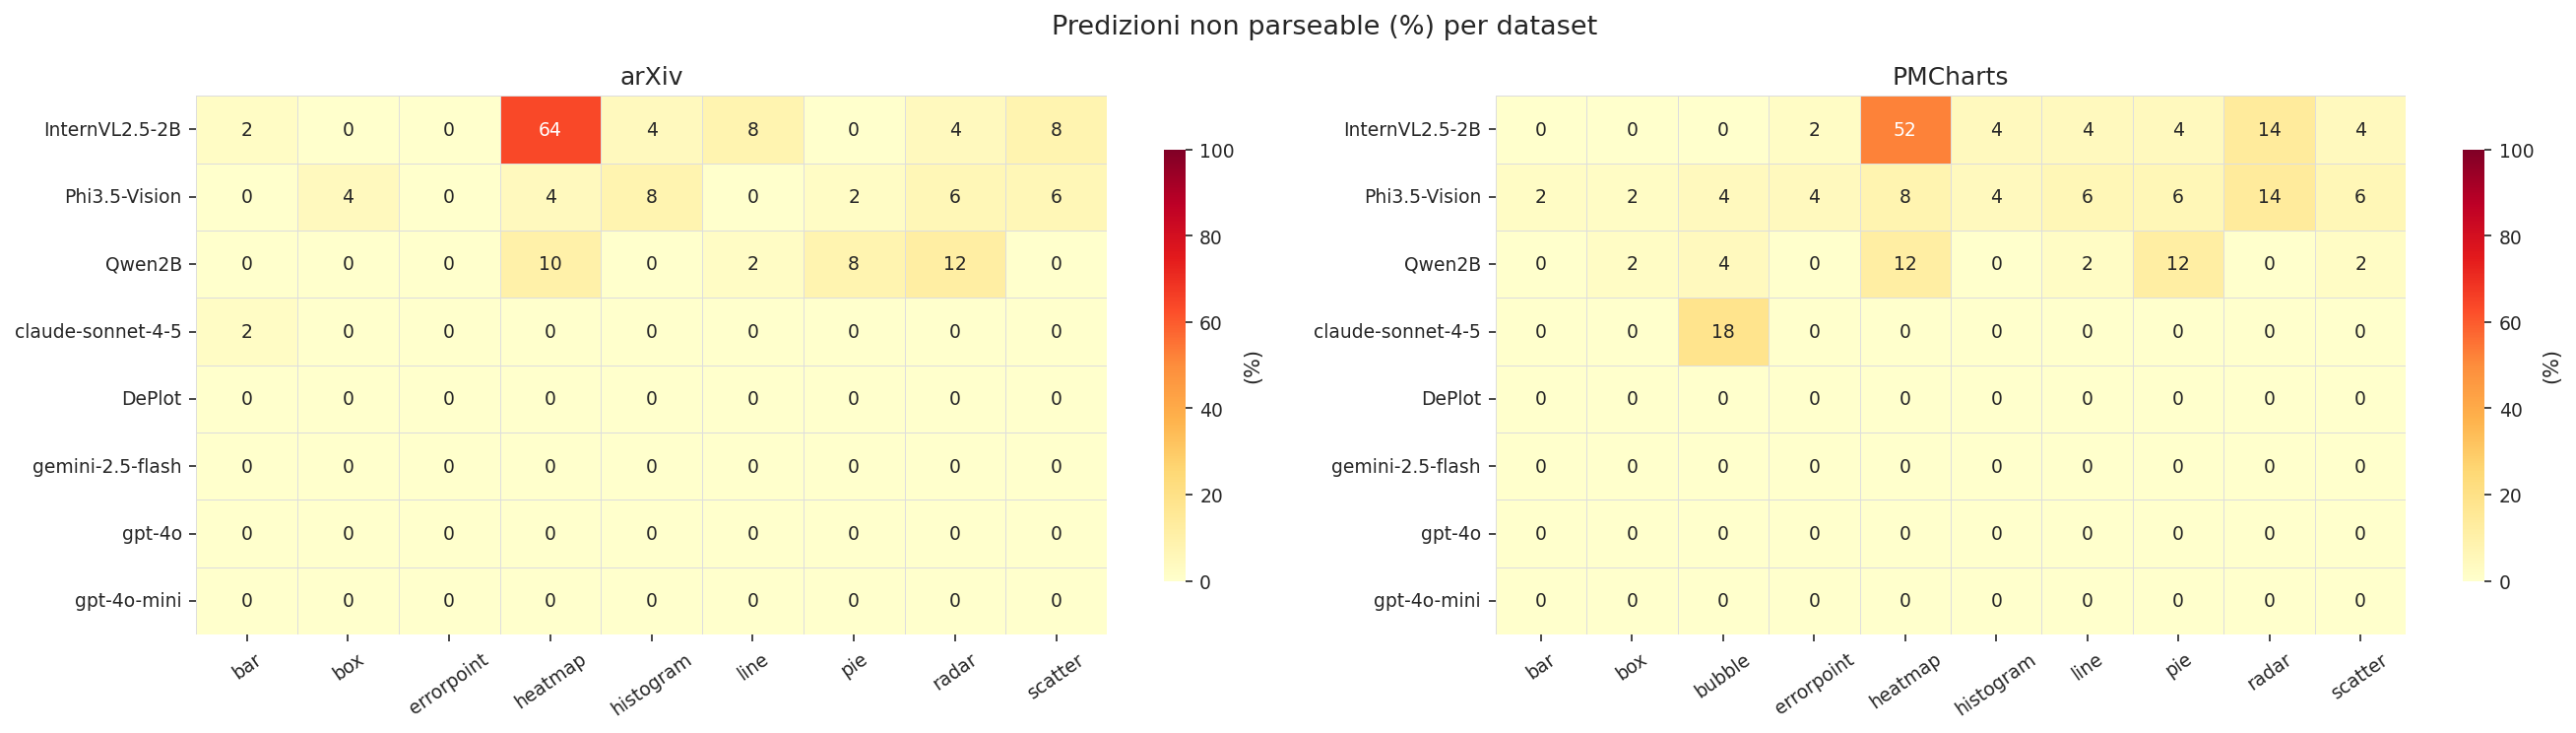

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, ds in zip(axes, DATASETS):
    sub = df[(df['dataset'] == ds) & (df['status'] != 'not_supported')].copy()
    sub_tot = sub.groupby(['model', 'chart_class'])['filename'].count().rename('total')
    sub_fail = sub.groupby(['model', 'chart_class'])['failed'].sum().rename('failed')
    sub_pct = (sub_fail / sub_tot * 100).unstack('chart_class').fillna(0)
    sub_pct = sub_pct.loc[model_order, [c for c in cc_order if c in sub_pct.columns]]

    sns.heatmap(
        sub_pct,
        annot=True, fmt='.0f', cmap='YlOrRd',
        vmin=0, vmax=100,
        linewidths=0.4, linecolor='#dddddd',
        cbar_kws={'label': '(%)', 'shrink': 0.8},
        ax=ax,
    )
    ax.set_title(f'{ds}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

fig.suptitle('Predizioni non parseable (%) per dataset', fontsize=13)
plt.tight_layout()
plt.show()

## Riepilogo per modello (media su tutte le classi)

,total,unparseable,pct
model,,,
InternVL2.5-2B,950,87,9.2
Phi3.5-Vision,950,43,4.5
Qwen2B,950,33,3.5
claude-sonnet-4-5,950,10,1.1
DePlot,300,0,0.0
gemini-2.5-flash,950,0,0.0
gpt-4o,950,0,0.0
gpt-4o-mini,950,0,0.0


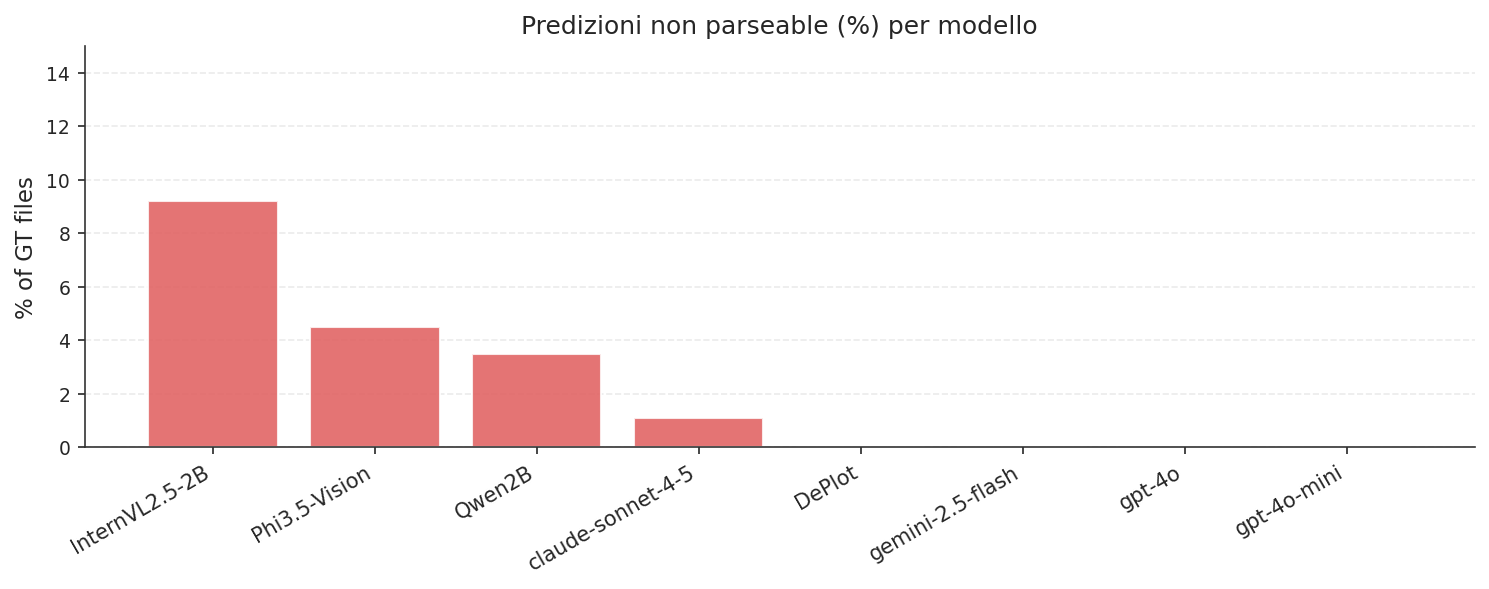

In [7]:
model_summary = (
    df[df['status'] != 'not_supported']
    .groupby('model')
    .apply(lambda g: pd.Series({
        'total':        len(g),
        'unparseable':  (g['status'] == 'unparseable').sum(),
    }))
    .assign(pct=lambda d: (d['unparseable'] / d['total'] * 100).round(1))
    .sort_values('pct', ascending=False)
)

display(model_summary)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(model_summary))
ax.bar(x, model_summary['pct'], color='#E05C5C', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(model_summary.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('% of GT files', fontsize=11)
ax.set_title('Predizioni non parseable (%) per modello', fontsize=12)
ax.set_ylim(0, 15)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## n_datapoints delle predizioni non parseable

n_datapoints — ok vs unparseable (tutti i modelli)


,ok,unparseable
count,6777.0,173.0
mean,15.4,21.9
std,12.4,14.6
min,1.0,4.0
25%,6.0,11.0
50%,12.0,20.0
75%,20.0,28.0
max,85.0,74.0



n_datapoints medi per predizioni unparseable — per modello


,count,mean,median,max
model,,,,
InternVL2.5-2B,87,19.0,16.0,48
Phi3.5-Vision,43,28.4,24.0,74
Qwen2B,33,21.7,20.0,66
claude-sonnet-4-5,10,19.9,20.0,25


/tmp/ipykernel_104525/3548864553.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/giorgiomelch/miniconda3/envs/checkct/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/giorgiomelch/miniconda3/envs/checkct/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


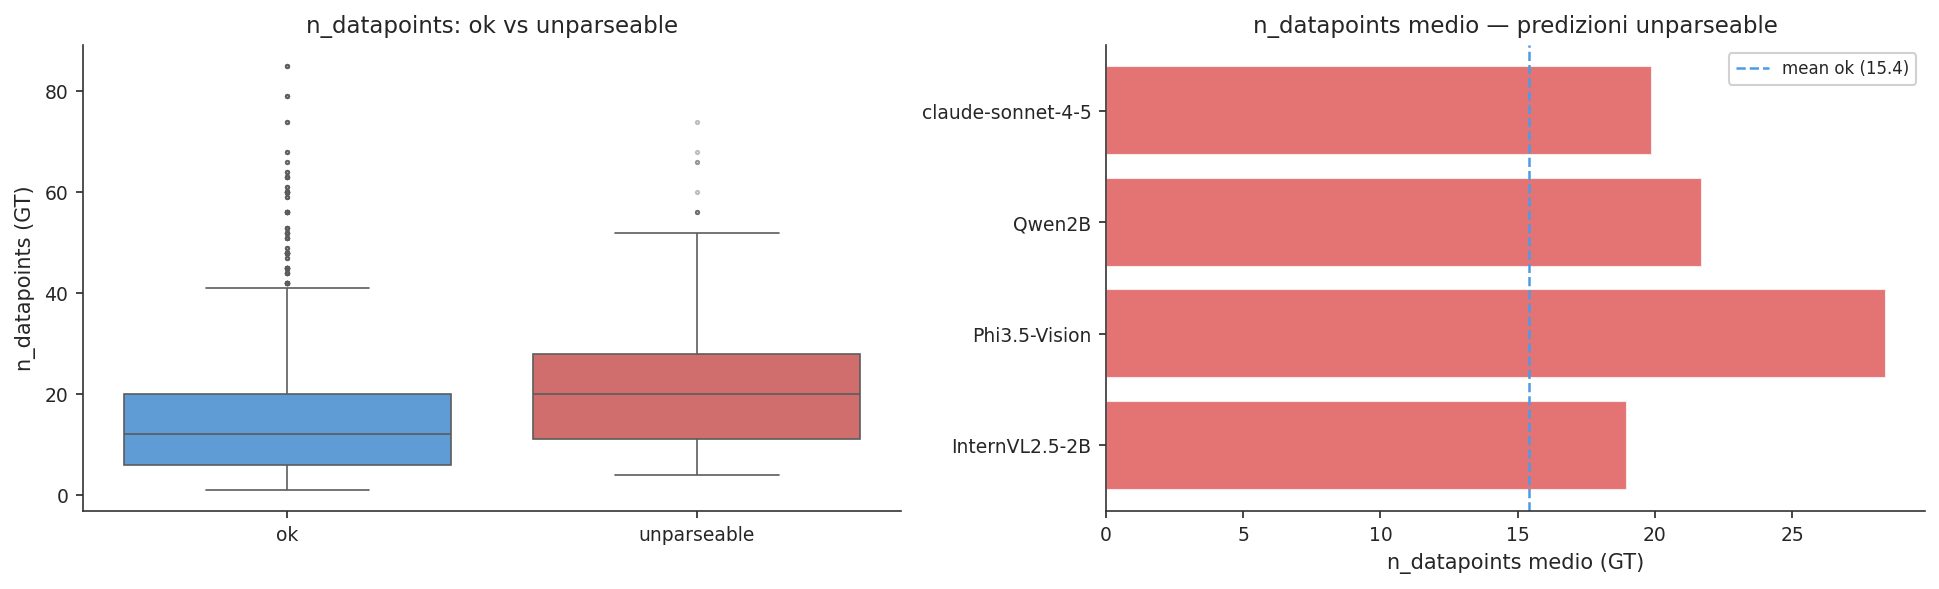

In [8]:
## Statistica n_datapoints per predizioni non parseable

df_ok   = df[df['status'] == 'ok']
df_fail = df[df['status'] == 'unparseable']

print('n_datapoints — ok vs unparseable (tutti i modelli)')
comparison = pd.DataFrame({
    'ok':          df_ok  ['n_datapoints'].describe(),
    'unparseable': df_fail['n_datapoints'].describe(),
}).round(1)
display(comparison)

print()
print('n_datapoints medi per predizioni unparseable — per modello')
per_model = (
    df_fail
    .groupby('model')['n_datapoints']
    .agg(count='count', mean='mean', median='median', max='max')
    .round(1)
    .sort_values('count', ascending=False)
)
display(per_model)

# boxplot confronto
df_plot = df[df['status'] != 'not_supported'].copy()
df_plot['gruppo'] = df_plot['status'].map(lambda s: 'unparseable' if s == 'unparseable' else 'ok')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# sinistra: distribuzione globale ok vs unparseable
sns.boxplot(
    data=df_plot, x='gruppo', y='n_datapoints',
    order=['ok', 'unparseable'],
    palette={'ok': '#4C9BE8', 'unparseable': '#E05C5C'},
    linewidth=0.8,
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=axes[0],
)
axes[0].set_title('n_datapoints: ok vs unparseable', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('n_datapoints (GT)', fontsize=10)
sns.despine(ax=axes[0])

# destra: n_datapoints medio per modello (solo unparseable, solo modelli con almeno 1)
per_model_plot = per_model[per_model['count'] > 0].reset_index()
axes[1].barh(per_model_plot['model'], per_model_plot['mean'],
             color='#E05C5C', alpha=0.85)
axes[1].axvline(df_ok['n_datapoints'].mean(), color='#4C9BE8',
                linestyle='--', linewidth=1.2, label=f'mean ok ({df_ok["n_datapoints"].mean():.1f})')
axes[1].set_xlabel('n_datapoints medio (GT)', fontsize=10)
axes[1].set_title('n_datapoints medio — predizioni unparseable', fontsize=11)
axes[1].legend(fontsize=8)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()